In [7]:
from matplotlib.gridspec import GridSpec
import networkx as nx
from itertools import product
from collections import defaultdict
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import circmean
from scipy.stats import circstd
from pathlib import Path
import sys
import numpy as np
import glob
import os
from scipy.stats import iqr
from scipy.ndimage import gaussian_filter


%load_ext autoreload
%autoreload

def get_parent_dir():
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)

sys.path.append(parent_dir)
from stimulus_experiments.entrainment_experiments import *
from stimulus_experiments.entrainment_analysis import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent directory: c:\Users\HP\ModellingProjects\Olivocerebellar-circuit


In [21]:
seedlist = np.arange(88, 92)
ISI_values = np.linspace(20, 200, 4)
for ISI in ISI_values:
    for seed in seedlist:
        print(f'python3 main_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean {ISI} --seed {seed}.txt')

python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 20.0 --seed 88.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 20.0 --seed 89.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 20.0 --seed 90.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 20.0 --seed 91.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 80.0 --seed 88.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 80.0 --seed 89.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on True --OU-stim-isi-mean 80.0 --seed 90.txt
python3 run_entrain.py --experiment specific-isi --run-type train --PFPC_plasticity-on Tru

- Test saving and loading state
- Set up command generator for training
- Set up argparse

- initialize network and runner objects function (without actually running)
- run until convergence function
- snapshot state function
- restore state function

 - parse argument function
 - main (for CLI) (passes config to single training and testing functions)

 - run_single_training_session function 
 - run_single_testing_session function

 - command generator function for all training conditions

Overview run functions/contrasts I need: 

-Training:
o Specific stimulus interval for training, "OU_stim_isi_mean", "OU_stim_amp_io_mean", "OU_stim_amp_pf_mean"
o Random stimulus interval for training, "OU_stim_isi_mean" , "OU_stim_isi_std", "OU_stim_amp_io_mean", "OU_stim_amp_pf_mean"
o No stimulus training / convergence, "OU_stim_amp_pf_mean" , "OU_stim_amp_io_mean"

-Testing:
o Specific stimulus trained with different ISI, plastic

o Specific stimulus trained with different ISI, static

o Specific stimulus trained with random ISI, plastic

o Specific stimulus trained with random ISI, static

o Random stimulus trained with different ISI, plastic

o Random stimulus trained with different ISI, static

o Random stimulus trained with random ISI, plastic

o Random stimulus trained with random ISI, static


o No stimulus trained with different ISI, plastic

o No stimulus trained with different ISI, static

o No stimulus trained with random ISI, plastic

o No stimulus trained with random ISI, static



In [ ]:
# Training experiments

In [9]:
#  Test for run_train

parent_dir = get_parent_dir()

results_dir = os.path.join(
    parent_dir, "results", f"stim_experiments_test_for_train_{time.strftime('%m-%d_%H;%M;%S')}"
)
snapshot_dir = os.path.join(
    parent_dir, "states", f"state_test_for_train_{time.strftime('%m-%d_%H;%M;%S')}"
)
figures_dir = os.path.join(
    parent_dir, "figures", f"state_test_for_train_{time.strftime('%m-%d_%H;%M;%S')}"
)

os.makedirs(results_dir, exist_ok=True)
os.makedirs(snapshot_dir , exist_ok=True)
os.makedirs(figures_dir , exist_ok=True)


run_path = os.path.join(results_dir, f"test_train_runner.npz")


net_params = {"PFPC_plasticity_on": True, 
             "OU_stim_pf_on": False,
            "OU_stim_io_on": False,
}

run_params = { "seed": 88,
        "dt": 0.025,
        "downsample": 50, 
        "max_runtime": 8_000,
}

config = {
        "net_params": net_params,
        "run_params": run_params,
       
        "snapshot_dir": snapshot_dir,
        "run_path": run_path,
        "figures_dir": figures_dir,

    }

net, data, state = run_train(config)




Not converged, t=8000 ms
Simulation time taken = 29.02840781211853 s
Saving checkpoint into C:\Users\HP\PycharmProjects\Internproject 2025\cerebellum-jax-main\states\state_test_for_train_05-27_09;37;56\_state.bp
Saving time taken: 0.15207934379577637 s 


In [ ]:
# Plot weights over time
max_time = np.max(data['ts'])
print(max_time)
figure_2DEF(seed = run_params['seed'], mon= data,  save= True, save_dir = config['figures_dir'],   threshold = 2, xrange = [0.001, max_time-1])

In [12]:
print(state.items())


dict_items([('CerebellarNetwork3', {}), ('PFBundles3', {'PFBundles3.I_OU': Array([1.2258683, 0.8519133, 0.8873093, 1.7224342, 1.060859 ], dtype=float32), 'PFBundles3.rho': Array([0.07413161, 0.44808668, 0.41269064, 0.4224342 , 0.23914099],      dtype=float32), 'PFBundles3.I_stim': Array([0., 0., 0., 0., 0.], dtype=float32)}), ('PurkinjeCell3', {'PurkinjeCell3.V': Array([-58.50077 , -56.600273, -51.23742 , -55.692642, -55.66595 ,
       -55.42416 , -51.670155, -54.212215, -57.10386 , -68.10723 ,
       -56.74092 , -53.20556 , -54.791576, -54.37496 , -55.6461  ,
       -53.2466  , -50.62911 , -54.352684, -56.144375, -55.784573,
       -56.364334, -54.172005, -51.95771 , -55.441967, -52.94843 ,
       -50.58377 , -52.44963 , -54.5076  , -55.821598, -53.810707,
       -55.009968, -53.139412, -49.231564, -55.31093 , -52.721046,
       -52.349644, -53.03814 , -56.975   , -60.800713, -54.469505,
       -51.311806, -57.289497, -61.81265 , -60.023   , -55.763897,
       -49.631275, -58.51944 , 

In [17]:
# Test for restoring network

parent_dir = get_parent_dir()
results_dir = os.path.join(
    parent_dir, "results", f"stim_experiments_test_for_test_{time.strftime('%m-%d_%H;%M;%S')}"
)
run_path = os.path.join(results_dir, f"test_test_runner.npz")

net_params = {"PFPC_plasticity_on": False, 
             "OU_stim_pf_on": True,
            "OU_stim_io_on": True,
}

run_params = { "seed": 88,
        "dt": 0.025,
        "simdur": 100_000,
        "downsample": 50, 
}

config = {
    'net_params': net_params,
    'run_params': run_params,
    'pretrain_snapshot_dir': snapshot_dir,
    'run_path':  run_path,

}

## Within run_test
new_net, new_runner = init_net_and_runner(net_params, seed= run_params['seed'])
print("Before - :", new_net.vars())

state, meta = load_snapshot(config['pretrain_snapshot_dir'])
bp.load_state(new_net, state)
print("After - :", new_net.vars())



print(state.items())


Before - : {'PFBundles8.I_OU': Variable(
  value=ShapedArray(float32[5]),
  _batch_axis=None,
  axis_names=None
), 'PFBundles8.rho': Variable(
  value=ShapedArray(float32[5]),
  _batch_axis=None,
  axis_names=None
), 'PFBundles8.I_stim': Variable(
  value=ShapedArray(float32[5]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.V': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.w': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.input': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.dbg_leak': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.dbg_exp': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.dbg_current': Variable(
  value=ShapedArray(float32[100]),
  _batch_axis=None,
  axis_names=None
), 'PurkinjeCell8.dbg_w'

KeyError: 'CerebellarNetwork8'

In [ ]:
print(data.keys())
print(snapshot_dir)



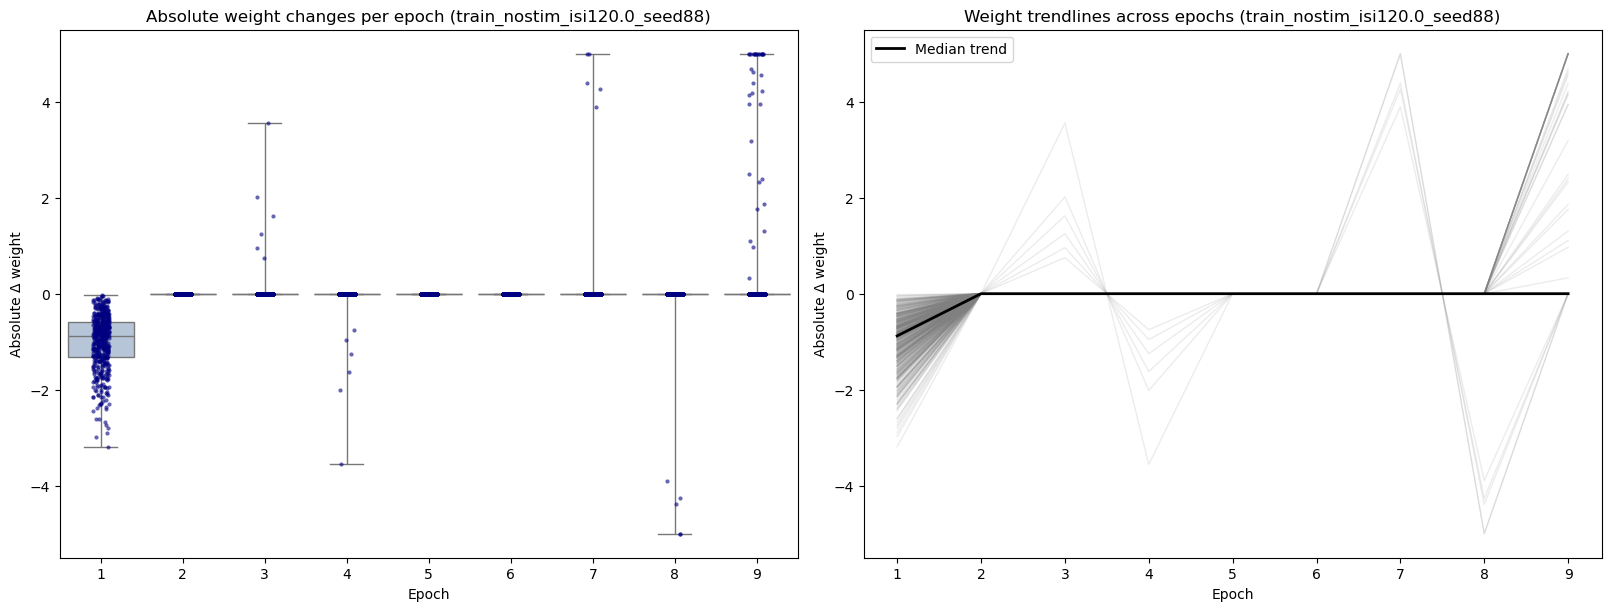

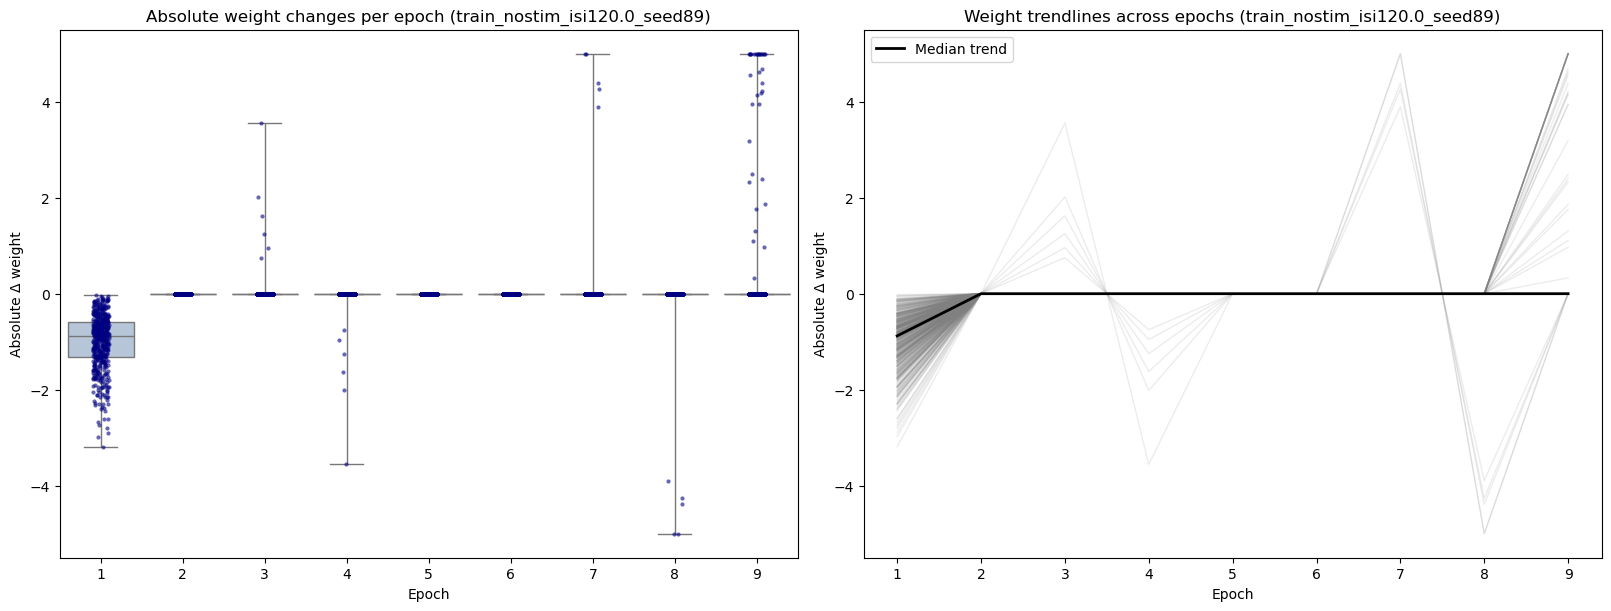

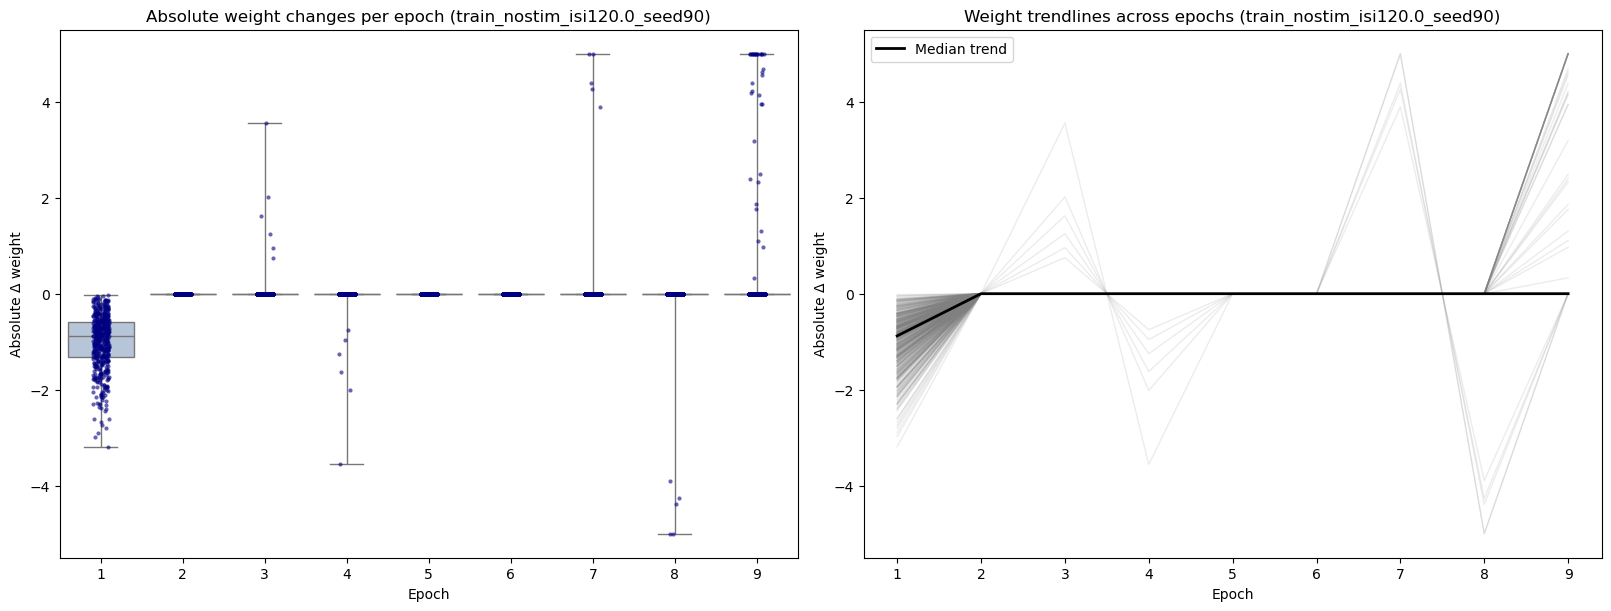

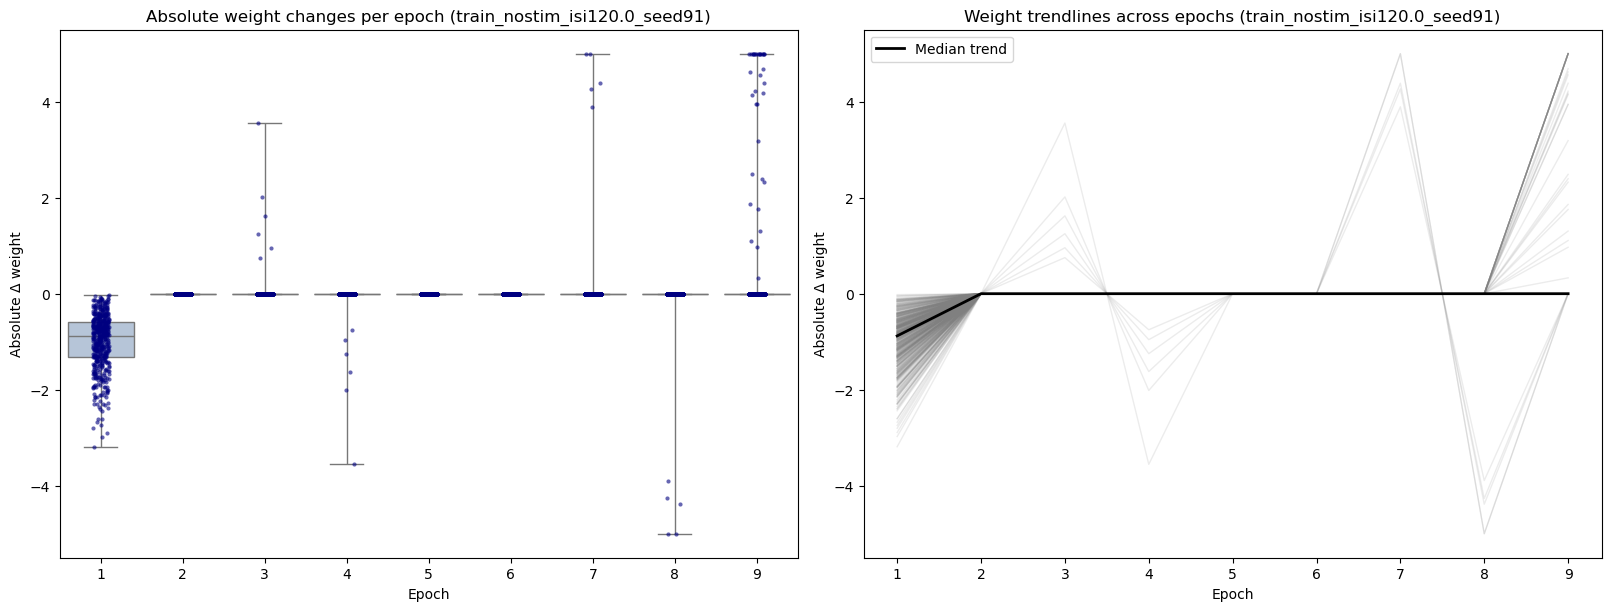

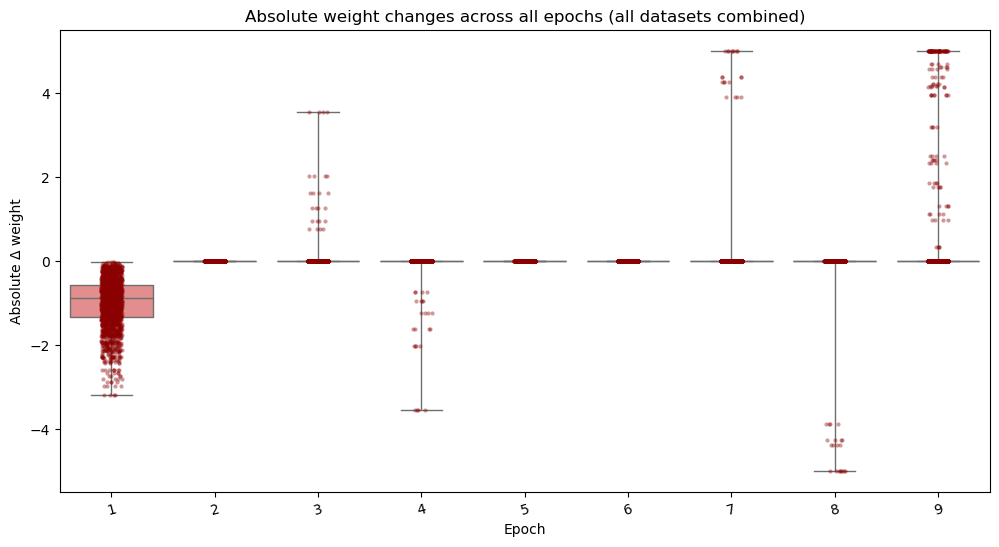

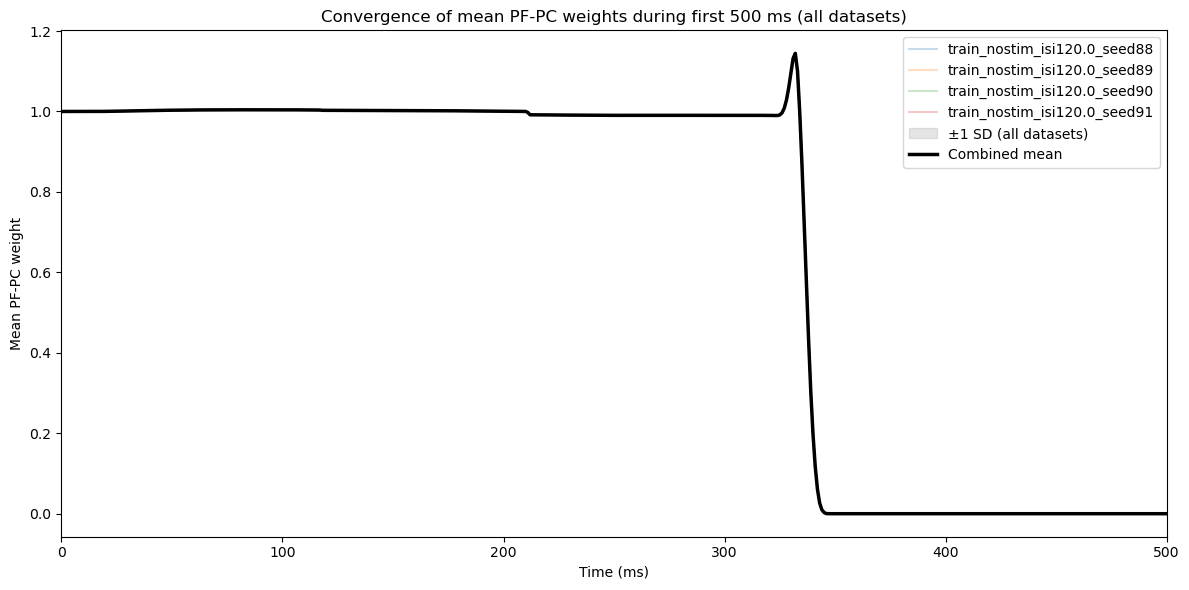

In [ ]:
# Load baseline run datasets
datasets = [
    r'C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_nostim_06-11_12;57;34\train_nostim_isi120.0_seed88.npz',
    r'C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_nostim_06-11_12;57;58\train_nostim_isi120.0_seed89.npz',
    r'C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_nostim_06-11_12;58;23\train_nostim_isi120.0_seed90.npz',
    r'C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_nostim_06-11_12;58;48\train_nostim_isi120.0_seed91.npz',
]

chunk_size = 1000  # ms

all_rows = []

for dataset in datasets:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    weights = data['pfpc_weights']

    weights_p_chunk = weights[::int(chunk_size)]
    ts_chunks = ts[::int(chunk_size)]
    n_chunks = weights_p_chunk.shape[0]
    if n_chunks < 2:
        continue

    init_weights = weights_p_chunk[0]
    delta_weights_abs = np.diff(weights_p_chunk, axis=0)
    delta_weights_rel = delta_weights_abs / init_weights

    for epoch_idx in range(delta_weights_abs.shape[0]):
        for weight_idx in range(delta_weights_abs.shape[1]):
            all_rows.append({
                'dataset': label,
                'epoch': epoch_idx + 1,
                'weight_index': weight_idx,
                'abs_delta': delta_weights_abs[epoch_idx, weight_idx],
                'rel_delta': delta_weights_rel[epoch_idx, weight_idx],
                'time_ms': ts_chunks[epoch_idx + 1],
            })

all_df = pd.DataFrame(all_rows)

for label, group in all_df.groupby('dataset'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    sns.boxplot(
        x='epoch',
        y='abs_delta',
        data=group,
        ax=axes[0],
        color='lightsteelblue',
        whis=[0, 100],
        showfliers=False,
    )
    sns.stripplot(
        x='epoch',
        y='abs_delta',
        data=group,
        ax=axes[0],
        color='navy',
        alpha=0.6,
        size=3,
        jitter=True,
    )
    axes[0].set_title(f'Absolute weight changes per epoch ({label})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Absolute Δ weight')

    epoch_order = sorted(group['epoch'].unique())
    for weight_idx, weight_group in group.groupby('weight_index'):
        weight_data = weight_group.sort_values('epoch')
        axes[1].plot(
            epoch_order,
            weight_data['abs_delta'],
            color='gray',
            alpha=0.15,
            linewidth=1,
        )

    median_by_epoch = group.groupby('epoch')['abs_delta'].median().reindex(epoch_order)
    axes[1].plot(epoch_order, median_by_epoch, color='black', linewidth=2, label='Median trend')
    axes[1].set_title(f'Weight trendlines across epochs ({label})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Absolute Δ weight')
    axes[1].legend()

    plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='lightcoral',
    whis=[0, 100],
    showfliers=False,
)
sns.stripplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='darkred',
    alpha=0.4,
    size=3,
    jitter=True,
)
ax.set_title('Absolute weight changes across all epochs (all datasets combined)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Absolute Δ weight')
plt.xticks(rotation=15)
plt.show()

# Plot convergence toward a stable mean within the first 200 ms
window = 500 # ms
convergence_rows = []
for dataset in datasets:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    weights = data['pfpc_weights']
    mask = ts <= window
    if np.sum(mask) == 0:
        continue

    ts_short = ts[mask]
    weights_short = weights[mask]

    for weight_idx in range(weights_short.shape[1]):
        for t, w in zip(ts_short, weights_short[:, weight_idx]):
            convergence_rows.append({
                'dataset': label,
                'weight_idx': weight_idx,
                'time_ms': t,
                'weight': w,
            })

convergence_df = pd.DataFrame(convergence_rows)
if not convergence_df.empty:
    plt.figure(figsize=(12, 6))
    
    # Plot individual weight trajectories (faintly)
    for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        plt.plot(group['time_ms'], group['weight'], alpha=0.01, color='gray')

    # Interpolate all individual weight trajectories to a common 1-ms grid
    time_grid = np.arange(0, window + 1, 1)
    interpolated = []
    for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        group_sorted = group.sort_values('time_ms')
        interp = np.interp(time_grid, group_sorted['time_ms'], group_sorted['weight'])
        interpolated.append(interp)

    combined_means = np.vstack(interpolated).mean(axis=0)
    combined_std = np.vstack(interpolated).std(axis=0)

    plt.fill_between(
        time_grid,
        combined_means - combined_std,
        combined_means + combined_std,
        color='gray',
        alpha=0.2,
        label='±1 SD (all datasets)',
    )
    plt.plot(time_grid, combined_means, color='black', linewidth=2.5, label='Combined mean')
    plt.title(f'Convergence of mean PF-PC weights during first {window} ms (all datasets)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Mean PF-PC weight')
    plt.xlim(0, window)
    plt.legend()
    plt.tight_layout()
    plt.show()